In [97]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import logging
from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from collections import defaultdict
import pandas as pd
from manifold.decoding.functions.utils import check_config_decoding
import numpy as np
import pickle as pkl
from manifold.decoding.functions import nulldistributions
from communication_subspace.ibl_communication.utils import load_widefield_epoch
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import warnings
from matplotlib import pyplot as plt
warnings.filterwarnings("ignore")
from manifold.utils import get_trial_masks


In [2]:
%load_ext autoreload 
%autoreload 2

In [3]:
one = ONE(mode="local")
sessions_all = one.search(datasets="widefieldU.images.npy")
sessions_all = np.asarray([str(s) for s in sessions_all])  # type: ignore

session_id = sessions_all[0]

In [ ]:

ssl = SessionLoader(one, session_id)
ssl.load_trials(collection="alf")
trials = ssl.trials.copy()

out = np.nan_to_num(trials.contrastLeft) - np.nan_to_num(trials.contrastRight)
trials["signcont"] = out
trials["stim_side"] = np.sign(trials["signcont"])



_, stimulus_behavioral_mask = load_trials_and_mask(
        one,
        session_id,
        exclude_nochoice=False,
        exclude_unbiased=False,
    )
stimulus_non_zero_mask = trials["signcont"] != 0
stim_mask = stimulus_behavioral_mask & stimulus_non_zero_mask
_, choice_behavioral_mask = load_trials_and_mask(
        one,
        session_id,
        exclude_nochoice=True,
        exclude_unbiased=False,
    )
choice_mask = choice_behavioral_mask

In [5]:
combined_mask = choice_mask & stim_mask

In [20]:

def return_labels(trials, condition):
    masks, _ = get_trial_masks(trials)
    n_trials = len(masks['Congruent_correct'])
    labels = np.zeros(n_trials)

    if condition == 'congruence':
        conda = masks['Congruent_correct'] | masks['Congruent_incorrect']
        condb = masks['Incongruent_correct'] | masks['Incongruent_incorrect']       

    elif condition == 'correctness':
        conda = masks['Incongruent_correct']
        condb = masks['Incongruent_incorrect']

    labels[conda] = 1
    labels[condb] = -1 

    valid_mask = conda|condb # type: ignore
    return labels, valid_mask

In [21]:
# trials_masked = trials[combined_mask]

In [109]:
labels, conditions = return_labels(trials, 'correctness')

In [110]:
final_mask = combined_mask & conditions

In [147]:
labels_masked

array([ 1., -1., -1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1.,
        1.,  1.,  1., -1., -1., -1., -1.,  1.,  1., -1., -1., -1.,  1.,
       -1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.,  1.,  1.,
        1.,  1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,  1.,
       -1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1.,
        1., -1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1., -1., -1.,
        1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,
       -1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.])

In [146]:
trials[final_mask]

,goCueTrigger_times,quiescencePeriod,stimOff_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,probabilityLeft,feedback_times,feedbackType,rewardVolume,firstMovement_times,intervals_0,intervals_1,signcont,stim_side
90,475.412562,0.467033,477.345683,475.413410,475.788966,-1.0,475.412371,NaN,1.0000,0.8,475.789027,1.0,1.5,475.537883,474.878256,477.845789,-1.0000,-1.0
100,522.131321,0.644046,526.511469,522.132158,523.965218,1.0,522.131120,NaN,0.1250,0.8,523.966067,-1.0,0.0,523.774883,521.407922,527.011515,-0.1250,-1.0
110,567.063649,0.682714,569.894122,567.064670,567.332347,1.0,567.063538,NaN,0.1250,0.8,567.333238,-1.0,0.0,567.184883,565.433061,570.394126,-0.1250,-1.0
112,574.744214,0.425620,576.680160,574.745149,575.109519,-1.0,574.744110,NaN,0.0625,0.8,575.109627,1.0,1.5,575.003883,574.251909,577.180245,-0.0625,-1.0
126,634.962719,0.449468,637.962374,634.963381,635.412018,1.0,634.962531,NaN,0.2500,0.8,635.413008,-1.0,0.0,635.072883,634.360920,638.462514,-0.2500,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,4469.997333,0.693822,4472.947270,4469.998120,4470.395134,-1.0,4469.997082,0.0625,NaN,0.2,4470.396110,-1.0,0.0,4470.185883,4469.241032,4473.447342,0.0625,1.0
948,4510.546762,0.509674,4512.727336,4510.547640,4511.173363,1.0,4510.546602,0.0625,NaN,0.2,4511.173512,1.0,1.5,4510.955883,4509.984261,4513.227368,0.0625,1.0
951,4526.327120,0.674000,4528.129640,4526.327827,4526.570122,1.0,4526.326978,0.1250,NaN,0.2,4526.570246,1.0,1.5,4526.452883,4525.586315,4528.629739,0.1250,1.0
952,4530.493842,0.567299,4532.412757,4530.494738,4530.853241,1.0,4530.493605,0.1250,NaN,0.2,4530.853363,1.0,1.5,4530.618883,4529.865845,4532.912836,0.1250,1.0


In [180]:
# lets see: load significant ones
with open("../data/processed/significant_stims_choice.pkl",'rb') as f:
    signies = pkl.load(f)

In [181]:
stim_r = signies[session_id]['stim']
choice_r = signies[session_id]['choice']

In [195]:
stim_r =[ [x] for x in stim_r]

In [201]:
region_names[0]

['MOB']

In [197]:
config = check_config_decoding()
stim_data, region_names = load_widefield_epoch(
    one, session_id, trials, config["hemisphere"], epoch="stim", regions=stim_r
) # we can also use response time = False to default back to firstMovement times. 

7

In [165]:
choice_data, region_names = load_widefield_epoch(
    one, session_id, trials, config["hemisphere"], epoch="choice", regions=[["MOs"]], response_time=True
) # we can also use response time = False to default back to firstMovement times. 

In [191]:
stim_data[0].shape

(2, 958, 578)

In [167]:
A = stim_data[0][:, final_mask, :]
B = choice_data[0][:, final_mask,:]

In [168]:
labels_masked = labels[final_mask]

In [169]:
stim_frame = A[1,:]-A[0,:]
choice_frame = B[0, :]

In [170]:
from sklearn.decomposition import PCA


pca = PCA(n_components=1)
stim_pca = pca.fit_transform(stim_frame)
choice_pca = pca.fit_transform(choice_frame)

In [171]:
from manifold.widefield_ppi import compute_ppi_interaction

In [172]:
results = compute_ppi_interaction(Y=choice_frame, X=stim_frame, labels=labels_masked, reduction="mean")

In [199]:
results.params[3]

np.float64(-0.07582965420873947)

In [174]:
import seaborn as sns

In [175]:
df = pd.DataFrame({
    'Y': choice_pca.reshape(-1,), 
    'X': stim_pca.reshape(-1,),
    'condition': labels_masked 
})
df['X_centered'] = df['X'] - df['X'].mean()
df['cond_centered'] = df['condition'] - df['condition'].mean()

In [176]:
df['Task State'] = np.where(df['condition'] == 1, 'Correct', 'Incorrect')

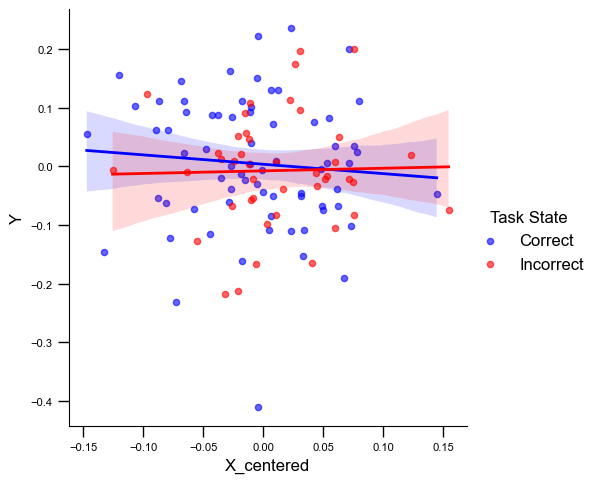

In [177]:
sns.lmplot(
    data=df, 
    x='X_centered', 
    y='Y', 
    hue='Task State', 
    palette=['blue', 'red'],
    scatter_kws={'alpha': 0.6, 's': 20}, # Adjust point transparency and size
    line_kws={'linewidth': 2}
)

In [178]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.3527
Date:                Wed, 24 Jun 2026   Prob (F-statistic):              0.787
Time:                        23:11:57   Log-Likelihood:                 391.96
No. Observations:                 113   AIC:                            -775.9
Df Residuals:                     109   BIC:                            -765.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0075      0.001      9.841      0.000       0.006       0.009
x1            -0.0453      0.152     -0.299      0.766      -0.346       0.255
x2             0.0005      0.001      0.714      0.477      -0.001       0.002
x3            -0.0758      0.152     -0.500      0.618      -0.377       0.225
==============================================================================
Omnibus:                        8.432   Durbin-Watson:                   2.280
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                9.618
Skew:                          -0.457   Prob(JB):                      0.00816
Kurtosis:                       4.099   Cond. No.                         269.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [202]:
q = pkl.load(open('../data/generated/wifi/ppis/f7d46a15-9498-40dc-90da-fb977ce844be_ppi_significant_regions_pca.pkl','rb'))